# Notebook 05 (Exp 2) — Full Fine-Tuning (FFT)

Fixes vs Exp 1:
- **`learning_rate=5e-5`** — exp1 used 2e-5; both train and val loss plateaued around 1.05 indicating underfitting
- Raising LR 2.5x should allow the model to actually descend faster
- All other hyperparams identical to exp1

**Model**: Qwen2.5-1.5B-Instruct (same as exp1; 1.5B keeps FFT within 8GB VRAM)  
**Output**: `outputs/exp2/fft/`

In [1]:
import sys
import gc
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset
from src.training_utils import build_fft_training_args_exp2

from trl import SFTTrainer

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'exp2' / 'fft'
FIG_DIR       = ROOT / 'outputs' / 'exp2' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

print('Setup complete.')
print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Setup complete.
GPU:  NVIDIA RTX PRO 5000 Blackwell
VRAM: 50.8 GB


## 1. Load Datasets

In [2]:
train_dataset = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'train.jsonl')
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')
print('Train:', train_dataset)
print('Val:  ', val_dataset)


Train: Dataset({
    features: ['messages'],
    num_rows: 40084
})
Val:   Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model (BF16, All Parameters Trainable)

In [3]:
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization=None,
    attn_implementation='eager',
)

print_model_info(model)

if torch.cuda.is_available():
    print(f'VRAM after model load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Total parameters:     1,543,714,304
Trainable parameters: 1,543,714,304  (100.00%)
VRAM after model load: 3.09 GB


## 3. Training Configuration (Exp 2 — LR=5e-5)

In [4]:
training_args = build_fft_training_args_exp2(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    # ~36 GB effective VRAM (other processes consume ~11 GB of 47 GB)
    per_device_train_batch_size=8,    # was 16; OOM at 16 due to ~8 GB logits alloc
    gradient_accumulation_steps=2,    # effective batch = 16 preserved
    max_length=512,
    gradient_checkpointing=True,      # re-enabled; reduces activation memory ~40%
    dataloader_num_workers=4,
)

print('Key FFT training arguments (Exp 2):')
print(f'  per_device_train_batch_size:  {training_args.per_device_train_batch_size}')
print(f'  gradient_accumulation_steps:  {training_args.gradient_accumulation_steps}')
print(f'  effective batch size:         {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  learning_rate:                {training_args.learning_rate}  (exp1: 2e-5, exp2: 5e-5)')
print(f'  optimizer:                    {training_args.optim}')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Key FFT training arguments (Exp 2):
  per_device_train_batch_size:  8
  gradient_accumulation_steps:  2
  effective batch size:         16
  learning_rate:                5e-05  (exp1: 2e-5, exp2: 5e-5)
  optimizer:                    OptimizerNames.ADAMW_TORCH_FUSED


## 4. Train

In [5]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

# Check if complete, or find latest checkpoint to resume
_final = OUTPUT_DIR / 'final_model'
if _final.exists():
    print(f'Training already complete — found {_final.name}')
    print('Delete final_model/ to re-train.')
    train_result = None
else:
    _ckpts = sorted(
        (OUTPUT_DIR / 'checkpoints').glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    ) if (OUTPUT_DIR / 'checkpoints').exists() else []
    _resume = str(_ckpts[-1]) if _ckpts else None
    print(f'Resuming from: {_resume}' if _resume else 'Starting FFT training (Exp 2, LR=5e-5) from scratch ...')
    train_result = trainer.train(resume_from_checkpoint=_resume)
    print(f'\nTraining complete.')
    print(f'  Train loss: {train_result.training_loss:.4f}')
    print(f'  Steps:      {train_result.global_step}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting FFT training (Exp 2, LR=5e-5) from scratch ...


Step,Training Loss,Validation Loss
200,1.067339,1.038999
400,0.977564,1.028082
600,0.781485,1.070479
800,0.736595,1.092294
1000,0.607059,1.168553
1200,0.596556,1.172705
1254,0.599707,1.172484


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training complete.
  Train loss: 0.8337
  Steps:      1254


## 5. Save Full Fine-Tuned Model

In [6]:
model_path = str(OUTPUT_DIR / 'final_model')
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f'FFT model (Exp 2) saved to: {model_path}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FFT model (Exp 2) saved to: /home/prasingh/data/Mormon-NLT/outputs/exp2/fft/final_model


In [7]:
log_path = OUTPUT_DIR / 'training_logs' / 'fft_log_history.json'
log_path.parent.mkdir(parents=True, exist_ok=True)
if train_result is not None:
    with open(log_path, 'w') as f:
        json.dump(trainer.state.log_history, f)
    print(f'Log history saved to: {log_path}')
else:
    print('Training was skipped — log not updated.')
    if log_path.exists(): print(f'Existing log at: {log_path}')

Log history saved to: /home/prasingh/data/Mormon-NLT/outputs/exp2/fft/training_logs/fft_log_history.json


## 6. Training Loss Curve

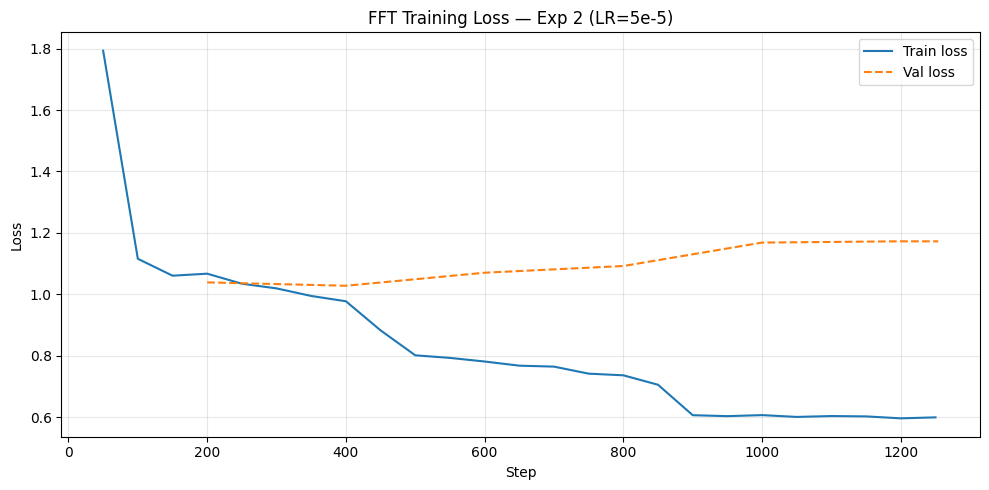

Figure saved to: /home/prasingh/data/Mormon-NLT/outputs/exp2/results/figures/fft_loss_curve.png

Final train loss: 0.5997
Best val loss:    1.0281  (step 400)


In [10]:
# Training Loss Curve
log_path = OUTPUT_DIR / 'training_logs' / 'fft_log_history.json'

if not log_path.exists():
    print(f'No training log found at:\n  {log_path}')
    print('Run training first, then re-run this cell.')
else:
    with open(log_path) as f:
        log_history = json.load(f)

    train_logs = [e for e in log_history if 'loss' in e and 'eval_loss' not in e]
    eval_logs  = [e for e in log_history if 'eval_loss' in e]

    fig, ax = plt.subplots(figsize=(10, 5))
    if train_logs:
        ax.plot([e['step'] for e in train_logs], [e['loss'] for e in train_logs],
                label='Train loss', linewidth=1.5)
    if eval_logs:
        ax.plot([e['step'] for e in eval_logs], [e['eval_loss'] for e in eval_logs],
                label='Val loss', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('FFT Training Loss — Exp 2 (LR=5e-5)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = FIG_DIR / 'fft_loss_curve.png'
    fig.savefig(out, dpi=150)
    plt.show()
    print(f'Figure saved to: {out}')

    if train_logs:
        print(f'\nFinal train loss: {train_logs[-1]["loss"]:.4f}')
    if eval_logs:
        best = min(eval_logs, key=lambda e: e['eval_loss'])
        print(f'Best val loss:    {best["eval_loss"]:.4f}  (step {best["step"]})')

In [ ]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')